In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from scipy.stats import mode
from sklearn.metrics import accuracy_score

In [2]:
# Step 1: Load the dataset
df = pd.read_csv('IRIS.csv')
print(df)
y = df['species'].astype('category').cat.codes

     sepal_length  sepal_width  petal_length  petal_width         species
0             5.1          3.5           1.4          0.2     Iris-setosa
1             4.9          3.0           1.4          0.2     Iris-setosa
2             4.7          3.2           1.3          0.2     Iris-setosa
3             4.6          3.1           1.5          0.2     Iris-setosa
4             5.0          3.6           1.4          0.2     Iris-setosa
..            ...          ...           ...          ...             ...
145           6.7          3.0           5.2          2.3  Iris-virginica
146           6.3          2.5           5.0          1.9  Iris-virginica
147           6.5          3.0           5.2          2.0  Iris-virginica
148           6.2          3.4           5.4          2.3  Iris-virginica
149           5.9          3.0           5.1          1.8  Iris-virginica

[150 rows x 5 columns]


In [3]:
# Step 2: Prepare the feature set
X = df.drop('species', axis=1)
print(X)

     sepal_length  sepal_width  petal_length  petal_width
0             5.1          3.5           1.4          0.2
1             4.9          3.0           1.4          0.2
2             4.7          3.2           1.3          0.2
3             4.6          3.1           1.5          0.2
4             5.0          3.6           1.4          0.2
..            ...          ...           ...          ...
145           6.7          3.0           5.2          2.3
146           6.3          2.5           5.0          1.9
147           6.5          3.0           5.2          2.0
148           6.2          3.4           5.4          2.3
149           5.9          3.0           5.1          1.8

[150 rows x 4 columns]


In [4]:
# Optional: Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(X_scaled)

[[-9.00681170e-01  1.03205722e+00 -1.34127240e+00 -1.31297673e+00]
 [-1.14301691e+00 -1.24957601e-01 -1.34127240e+00 -1.31297673e+00]
 [-1.38535265e+00  3.37848329e-01 -1.39813811e+00 -1.31297673e+00]
 [-1.50652052e+00  1.06445364e-01 -1.28440670e+00 -1.31297673e+00]
 [-1.02184904e+00  1.26346019e+00 -1.34127240e+00 -1.31297673e+00]
 [-5.37177559e-01  1.95766909e+00 -1.17067529e+00 -1.05003079e+00]
 [-1.50652052e+00  8.00654259e-01 -1.34127240e+00 -1.18150376e+00]
 [-1.02184904e+00  8.00654259e-01 -1.28440670e+00 -1.31297673e+00]
 [-1.74885626e+00 -3.56360566e-01 -1.34127240e+00 -1.31297673e+00]
 [-1.14301691e+00  1.06445364e-01 -1.28440670e+00 -1.44444970e+00]
 [-5.37177559e-01  1.49486315e+00 -1.28440670e+00 -1.31297673e+00]
 [-1.26418478e+00  8.00654259e-01 -1.22754100e+00 -1.31297673e+00]
 [-1.26418478e+00 -1.24957601e-01 -1.34127240e+00 -1.44444970e+00]
 [-1.87002413e+00 -1.24957601e-01 -1.51186952e+00 -1.44444970e+00]
 [-5.25060772e-02  2.18907205e+00 -1.45500381e+00 -1.31297673e

In [5]:
# Step 3: Train the K-Means model
kmeans = KMeans(n_clusters=3, random_state=42)  # Assuming we want to cluster into 3 groups
kmeans.fit(X_scaled)
#accuracy.kmeans()

KMeans(n_clusters=3, random_state=42)

In [6]:
# Step 5: Fix cluster labels and calculate accuracy
labels = np.zeros_like(kmeans.labels_)
for i in range(3):
    mask = (kmeans.labels_ == i)
    labels[mask] = mode(y[mask], keepdims=True).mode[0]

print("Clustering Accuracy:", accuracy_score(y, labels))

Clustering Accuracy: 0.6666666666666666


In [7]:
# Step 4: Make predictions
df['Cluster'] = kmeans.labels_  # Assign cluster labels to the original DataFrame

In [8]:
# Standardize the new data using the same scaler
new_data = pd.DataFrame({
    'sepal_length': [5.0, 6.5, 4.7],
    'sepal_width': [3.5, 2.8, 3.2],
    'petal_length': [1.6, 4.6, 1.3],
    'petal_width': [0.2, 1.5, 0.2]
})
new_data_scaled = scaler.transform(new_data)

# Predict the clusters for the new data
predicted_clusters = kmeans.predict(new_data_scaled)


# Display the predicted clusters
for i, cluster in enumerate(predicted_clusters):
    print(f"New data point {new_data.iloc[i].values} is predicted to be in cluster {cluster}")

New data point [5.  3.5 1.6 0.2] is predicted to be in cluster 1
New data point [6.5 2.8 4.6 1.5] is predicted to be in cluster 0
New data point [4.7 3.2 1.3 0.2] is predicted to be in cluster 2


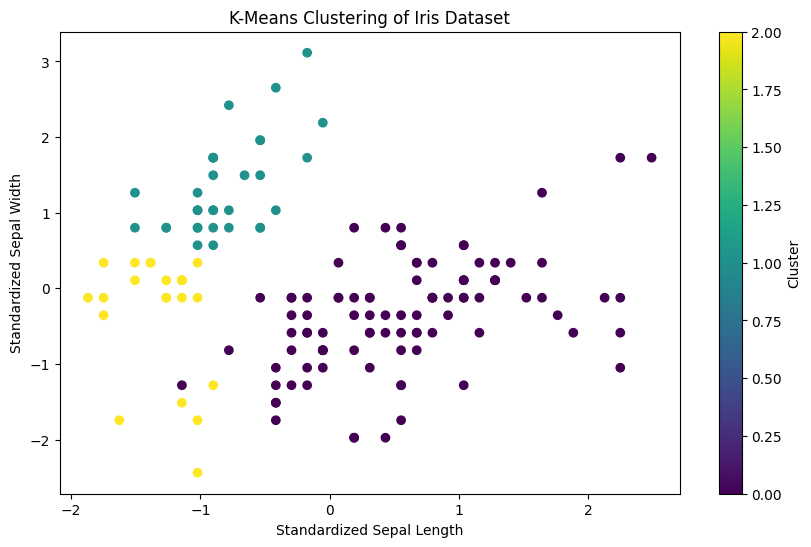

In [9]:
# Step 5: Visualize the clusters (using the first two features for 2D visualization)
plt.figure(figsize=(10, 6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=df['Cluster'], cmap='viridis', marker='o')
plt.title('K-Means Clustering of Iris Dataset')
plt.xlabel('Standardized Sepal Length')
plt.ylabel('Standardized Sepal Width')
plt.colorbar(label='Cluster')
plt.show()